<a href="https://colab.research.google.com/github/AditiNayak-S/MLT3011_Cloud-Infrastructure-Failure-Prediction/blob/main/notebooks/Machine_LearningTechniques_Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Techniques

## Lab 5: K-Nearest Neighbors and Support Vector Machine Classification

### Lab Objectives

- Prepare a cloud infrastructure monitoring dataset for binary classification.
- Implement K-Nearest Neighbors and Support Vector Machine classifiers.
- Apply feature scaling before model training.
- Compare the predictive performance of both classification algorithms.
- Visualize and interpret the classification results.

## Importing Required Libraries

The following libraries are required for data preprocessing, feature scaling, visualization, classification, and model evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

plt.style.use("dark_background")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")

Libraries imported successfully.


## Uploading and Loading the Dataset

The cloud infrastructure monitoring dataset is uploaded, extracted, and prepared for binary classification. A different application monitoring dataset is selected to evaluate K-Nearest Neighbors and Support Vector Machine classifiers.

In [ ]:
uploaded=files.upload()

Saving CIFPS - DATASET A.zip to CIFPS - DATASET A.zip
Saving CIFPS - DATASET B.zip to CIFPS - DATASET B.zip


In [ ]:
uploaded_files = list(uploaded.keys())

for file in uploaded_files:
    with zipfile.ZipFile(file,"r") as zip_ref:
        zip_ref.extractall()

DATASET_A_PATH = "cloud-monitoring-dataset-master/data"

selected_dataset = os.path.join(
    DATASET_A_PATH,
    "application-crash-rate-1",
    "app1-03.csv"
)

raw_df = pd.read_csv(selected_dataset)

display(raw_df.head())

,TimeStamp,Value,Label
0,2018-06-19 00:00:00,9.0,0
1,2018-06-19 01:00:00,19.0,0
2,2018-06-19 02:00:00,13.0,0
3,2018-06-19 03:00:00,6.0,0
4,2018-06-19 04:00:00,29.0,0


## Data Preparation

The timestamp attribute is converted into numerical temporal features suitable for machine learning. These engineered features are then used for classification.

In [ ]:
model_df = raw_df.copy()

model_df["TimeStamp"] = pd.to_datetime(model_df["TimeStamp"])

model_df["Hour"] = model_df["TimeStamp"].dt.hour
model_df["Minute"] = model_df["TimeStamp"].dt.minute
model_df["Second"] = model_df["TimeStamp"].dt.second
model_df["DayOfWeek"] = model_df["TimeStamp"].dt.dayofweek
model_df["IsWeekend"] = model_df["DayOfWeek"].isin([5,6]).astype(int)

model_df.drop(columns=["TimeStamp"], inplace=True)

display(model_df.head())

,Value,Label,Hour,Minute,Second,DayOfWeek,IsWeekend
0,9.0,0,0,0,0,1,0
1,19.0,0,1,0,0,1,0
2,13.0,0,2,0,0,1,0
3,6.0,0,3,0,0,1,0
4,29.0,0,4,0,0,1,0


## Feature Scaling

K-Nearest Neighbors and Support Vector Machine are distance-based machine learning algorithms. Therefore, feature scaling is performed using StandardScaler to ensure that all input features contribute equally during model training.

In [ ]:
X = model_df.drop(columns=["Label"])

y = model_df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [ ]:
before_scaling = pd.DataFrame({
    "Mean": X_train.mean().round(2),
    "Std Dev": X_train.std().round(2)
})

after_scaling = pd.DataFrame({
    "Mean": X_train_scaled.mean(axis=0).round(2),
    "Std Dev": X_train_scaled.std(axis=0).round(2)
}, index=X.columns)

display(
    before_scaling.join(
        after_scaling,
        lsuffix=" (Before)",
        rsuffix=" (After)"
    )
)

,Mean (Before),Std Dev (Before),Mean (After),Std Dev (After)
Value,139.84,155.99,-0.0,1.0
Hour,11.35,6.89,-0.0,1.0
Minute,0.00,0.00,0.0,0.0
Second,0.00,0.00,0.0,0.0
DayOfWeek,2.92,2.00,-0.0,1.0
IsWeekend,0.28,0.45,0.0,1.0


## K-Nearest Neighbors (KNN)

K-Nearest Neighbors classifies a data instance based on the majority class among its nearest neighbours in the feature space. Since KNN relies on distance calculations, feature scaling is essential for achieving reliable classification performance.

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

knn_predictions = knn.predict(X_test_scaled)

knn_probabilities = knn.predict_proba(X_test_scaled)[:,1]

print("KNN model trained successfully.")

KNN model trained successfully.


## Support Vector Machine (SVM)

Support Vector Machine constructs an optimal decision boundary that maximizes the separation between different classes. It is particularly effective for binary classification problems and performs well when features are properly scaled.

In [ ]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(
    X_train_scaled,
    y_train
)

svm_predictions = svm.predict(X_test_scaled)

svm_probabilities = svm.predict_proba(X_test_scaled)[:,1]

print("SVM model trained successfully.")

SVM model trained successfully.


## Model Evaluation

The K-Nearest Neighbors and Support Vector Machine classifiers are evaluated using multiple classification metrics. These metrics quantify the predictive performance of each model and enable a direct comparison between the two algorithms.

In [ ]:
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)
knn_auc = roc_auc_score(y_test, knn_probabilities)

svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)
svm_auc = roc_auc_score(y_test, svm_probabilities)

evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "K-Nearest Neighbors": [
        knn_accuracy,
        knn_precision,
        knn_recall,
        knn_f1,
        knn_auc
    ],
    "Support Vector Machine": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1,
        svm_auc
    ]
})

evaluation.iloc[:,1:] = evaluation.iloc[:,1:].round(4)

display(evaluation)

,Metric,K-Nearest Neighbors,Support Vector Machine
0,Accuracy,0.9014,0.9014
1,Precision,0.9130,1.0000
2,Recall,0.6364,0.5758
3,F1 Score,0.7500,0.7308
4,ROC-AUC,0.9322,0.9397


## ROC Curve Comparison

The Receiver Operating Characteristic (ROC) Curve compares the ability of the K-Nearest Neighbors and Support Vector Machine classifiers to distinguish between normal and failure events. A larger Area Under the Curve (AUC) indicates stronger classification performance.

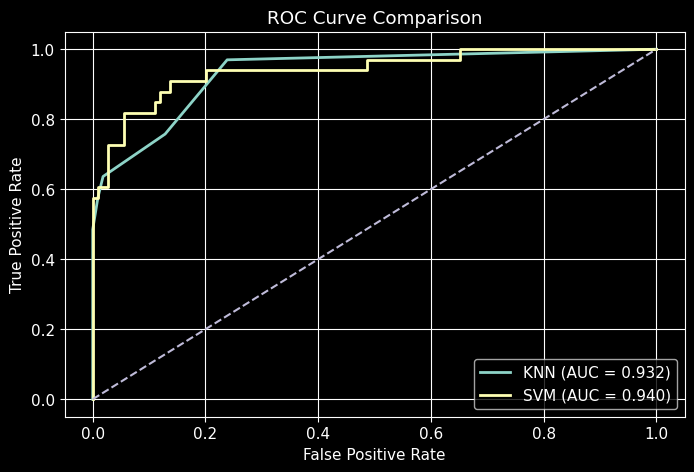

In [ ]:
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probabilities)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probabilities)

plt.figure()

plt.plot(
    knn_fpr,
    knn_tpr,
    linewidth=2,
    label=f"KNN (AUC = {knn_auc:.3f})"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    linewidth=2,
    label=f"SVM (AUC = {svm_auc:.3f})"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## Confusion Matrix - K-Nearest Neighbors

The confusion matrix summarizes the prediction outcomes of the K-Nearest Neighbors classifier by comparing the actual application status with the predicted status.

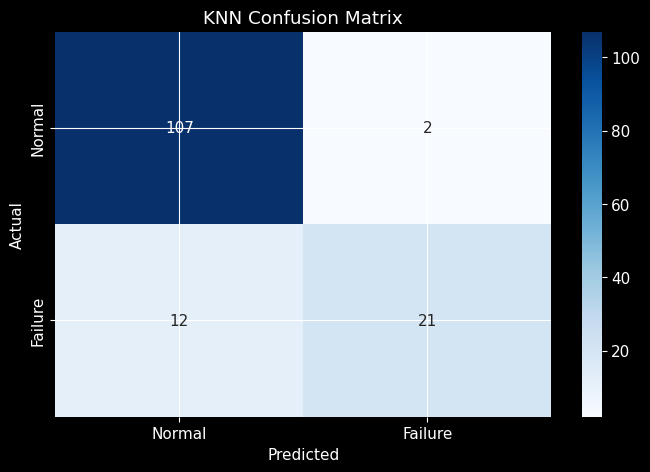

In [ ]:
knn_cm = confusion_matrix(
    y_test,
    knn_predictions
)

plt.figure()

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Failure"],
    yticklabels=["Normal","Failure"]
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Confusion Matrix - Support Vector Machine

The confusion matrix summarizes the prediction outcomes of the Support Vector Machine classifier by comparing the actual application status with the predicted status.

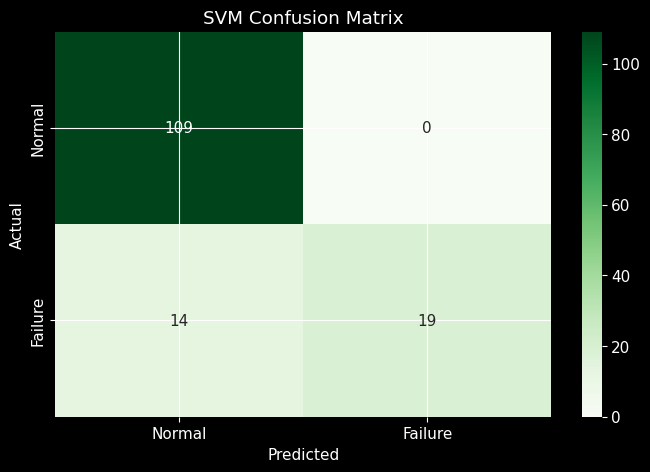

In [ ]:
svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

plt.figure()

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Normal","Failure"],
    yticklabels=["Normal","Failure"]
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Selecting the Optimal Value of K

The choice of K directly influences the performance of the K-Nearest Neighbors classifier. The following visualization evaluates different values of K to identify the value that provides the highest classification accuracy.

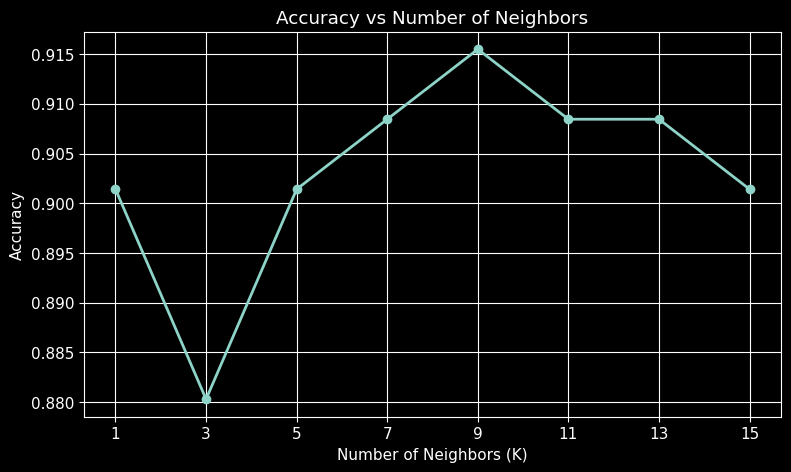

In [ ]:
k_values = [1,3,5,7,9,11,13,15]

accuracies = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    prediction = model.predict(
        X_test_scaled
    )

    accuracies.append(
        accuracy_score(
            y_test,
            prediction
        )
    )

plt.figure(figsize=(9,5))

plt.plot(
    k_values,
    accuracies,
    marker="o",
    linewidth=2
)

plt.xticks(k_values)

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Number of Neighbors")

plt.show()

## Performance Comparison of Classification Models

The following visualization compares the overall classification performance of the K-Nearest Neighbors and Support Vector Machine classifiers using multiple evaluation metrics.

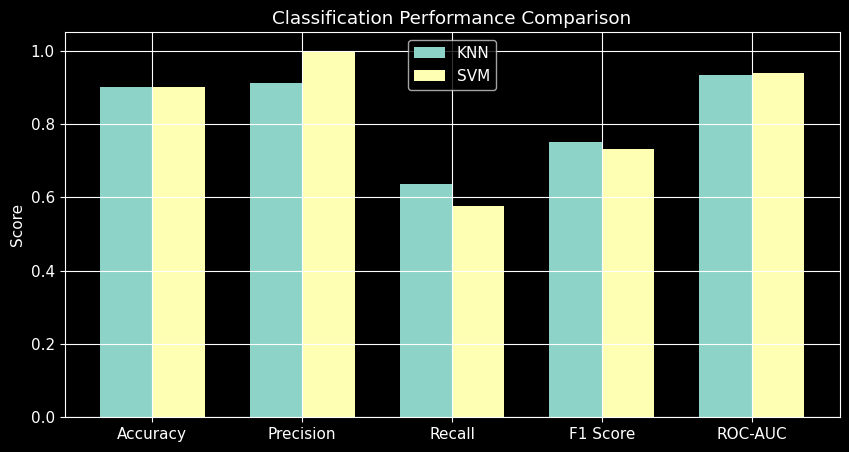

In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x-width/2,
    evaluation["K-Nearest Neighbors"],
    width,
    label="KNN"
)

plt.bar(
    x+width/2,
    evaluation["Support Vector Machine"],
    width,
    label="SVM"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")

plt.title("Classification Performance Comparison")

plt.legend()

plt.show()

## Best Model Selection

The classification performance of both algorithms is compared using the ROC-AUC score. The classifier with the higher ROC-AUC score is selected as the more suitable model for cloud infrastructure failure prediction.

In [ ]:
if svm_auc > knn_auc:
    best_model = "Support Vector Machine"
    reason = "Higher ROC-AUC score indicates better discrimination capability."
elif knn_auc > svm_auc:
    best_model = "K-Nearest Neighbors"
    reason = "Higher ROC-AUC score indicates better discrimination capability."
else:
    best_model = "Both Models"
    reason = "Both classifiers achieved identical ROC-AUC scores."

selection = pd.DataFrame({
    "Criterion":["ROC-AUC"],
    "Selected Model":[best_model],
    "Reason":[reason]
})

display(selection)

,Criterion,Selected Model,Reason
0,ROC-AUC,Support Vector Machine,Higher ROC-AUC score indicates better discrimi...


## Conclusion

In this laboratory experiment, K-Nearest Neighbors and Support Vector Machine classifiers were successfully implemented using a cloud infrastructure monitoring dataset. Feature scaling was applied prior to model training to ensure fair distance-based learning. Both classifiers were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC metrics, and their performance was compared through multiple visualizations. The experiment demonstrated the importance of feature scaling and comparative model evaluation when selecting an appropriate classifier for cloud infrastructure failure prediction.

In [ ]:
checklist = pd.DataFrame({
    "Task":[
        "Dataset prepared",
        "Feature engineering completed",
        "Feature scaling applied",
        "KNN classifier implemented",
        "SVM classifier implemented",
        "Models evaluated",
        "Visualizations generated",
        "Best model identified",
        "Experiment completed"
    ],
    "Status":["✓ Completed"]*9
})

display(checklist)

,Task,Status
0,Dataset prepared,✓ Completed
1,Feature engineering completed,✓ Completed
2,Feature scaling applied,✓ Completed
3,KNN classifier implemented,✓ Completed
4,SVM classifier implemented,✓ Completed
5,Models evaluated,✓ Completed
6,Visualizations generated,✓ Completed
7,Best model identified,✓ Completed
8,Experiment completed,✓ Completed
